In [1]:
import numpy as np
import os 
import struct
from datetime import datetime, date, timedelta 
import pandas as pd


In [5]:

RECL = 8510
input_file = "F:\\1132-ICE_VLF\\1132_19-04(5)\\DMT_N1_1132_149901_20070423_234407_20070424_001756.DAT"



In [6]:
Datetime =[]
Lt = []
Al = []
Lat = []
Long = []
dfArray = []
frq =[]

In [7]:


with open(input_file, 'rb') as f:
    piece = f.read(RECL)
    
    counter = 0  # count of the number of occurrences of RELC
    while piece:
        
        counter += 1
        datcds = [int.from_bytes(piece[:4], byteorder='big'), int.from_bytes(piece[4:8], byteorder='big')]
        day=np.mod(datcds[0],16777216)
        msec=datcds[1]
        record_date = date(1950, 1, 1) + timedelta(days=int(day))
        #print("Block 1")
        #print(f"mpd = {day}, msec = {msec}, date = {record_date}")
        i = 8; delta = 2 * 7
        time = struct.unpack('>'+'h'*7, piece[i:i+delta])
        #print(f"time = {time}")
        dt = datetime(year=int(time[0]), month=int(time[1]), day=int(time[2]), hour=int(time[3]),minute=int(time[4]), second=int(time[5]),microsecond=int(time[6])*1000)
        date_time = dt.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]
        start_time = datetime.strptime(date_time,'%Y-%m-%d %H:%M:%S.%f')
        #print(start_time)

        i = i + delta; delta = 2 * 2
      
        orb, sorb = struct.unpack('>hh', piece[i:i + delta])
        
        i = i + delta; delta = 8
       
        tms = "".join([s.decode() for s in struct.unpack('>' +'s'*8, piece[i:i+delta])])
       
        i = i + delta; delta = 4
        soft_cal = struct.unpack('>bbbb', piece[i:i + delta])
        
        i = i + delta; delta = 4*4
        orbp = struct.unpack('>ffff', piece[i:i+delta])
        #print(f"Geocentric_lat = {orbp[0]:.4f}, Geocentric_long = {orbp[1]:.4f}")
        #print(f"Altitude = {orbp[2]:.4f}, local_time = {orbp[3]:.4f}")
        Geocentric_lat = f"{orbp[0]:.4f}"
        Geocentric_long = f"{orbp[1]:.4f}"
        local_time = f"{orbp[3]:.4f}"
        Altitude = f"{orbp[2]:.3f}"
        i += delta; delta = 4*15
        geop = struct.unpack('>'+'f'*15, piece[i:i+delta])
        
      
        i += delta; delta = 4*3
        solp = struct.unpack('>'+'f'*3, piece[i:i+delta])
        
        i = i + delta; delta = 2
        vers = struct.unpack('>bb', piece[i:i + delta])
        
        i += delta; delta = 4*18
        attp = struct.unpack('>'+'f'*18, piece[i:i+delta])
        
        i = i + delta; delta = 2
        qi = struct.unpack('>h', piece[i:i + delta])[0]
        
        i = i + delta; delta = 2
        vers = struct.unpack('>bb', piece[i:i + delta])
        
        i = i + delta; delta = 21
        type = "".join([s.decode() for s in struct.unpack('>' +'s'*21, piece[i:i+delta])])
        
        i = i + delta; delta = 32
        hk = struct.unpack('>'+'c'*32, piece[i:i + delta])
        HKs = "".join([el.hex() for el in hk])
        
        i = i + delta; delta = 9
        coord = "".join([s.decode() for s in struct.unpack('>' +'s'*9, piece[i:i+delta])])
        
        i = i + delta; delta = 3
        name = "".join([s.decode() for s in struct.unpack('>' +'s'*3, piece[i:i+delta])])
        
        i = i + delta; delta = 16
        unit = "".join([s.decode('latin-1') for s in struct.unpack('>' +'s'*16, piece[i:i+delta])])
        
        i = i + delta; delta = 1
        nbsp = struct.unpack('>'+'b'*1, piece[i:i + delta])[0]
        #print(f"Number of consecutice spectra = {nbsp}")
        i = i + delta; delta = 2
        nbf = struct.unpack('>h', piece[i:i + delta])[0]
        #print(f"Number of spectrum frequencies  = {nbf}")
        i += delta; delta = 4
        dt = struct.unpack('>f', piece[i:i+delta])[0]
        #print(f"Time duration of one data array = {dt:.4f}")
        i += delta; delta = 4
        freq = struct.unpack('>f', piece[i:i+delta])[0]
        #print(f"Frequency resolution = {freq:.4f}")
        i += delta; delta = 4*2
        frange = struct.unpack('>ff', piece[i:i+delta])[0]
        #print(f"Frequency range = {frange:.4f}")
        i += delta; delta = 2 * 7
        idatsp = struct.unpack('>'+'h'*7, piece[i:i+delta])
        #print(f"time = {idatsp}")
        i += delta
        sp = struct.unpack('>2048f', piece[i:])
        sp_0 = sp[:1024]
        sp_1 = sp[1024:]
        sp0=list(sp_0)
        sp1=list(sp_1)
        data1 = {'spectrum_0': sp0, 'spectrum_1': sp1}
        # Create a Pandas data frame from the dictionary
        df = pd.DataFrame(data1)
        dfArray.append(df) 
        #sp = struct.unpack('>2048f', piece[i:])
        for i in range(nbf):
            time_delta = timedelta(seconds=i * 1/freq)
            current_time = start_time + time_delta

            current_time_str = current_time.strftime("%Y-%m-%d %H:%M:%S.%f")
            Datetime.append(current_time_str)
            Lt.append(local_time)
            Al.append(Altitude)
            Lat.append(Geocentric_lat)
            Long.append(Geocentric_long)
            frq.append(freq)
        piece = f.read(RECL)
     
 
print(f'the count of repeatation of relc : {counter}')
        

#k=df['spectrum_0']


the count of repeatation of relc : 495


In [8]:
Master =pd.concat(dfArray,axis=0)
Master = Master.reset_index(drop = True)  
OP = pd.DataFrame({'Geocentric_lat':Lat,'Geocentric_long':Long,'Altitude': Al,"Local_time":Lt,'frequency':frq})           
DT = pd.DataFrame(Datetime,columns=['Datetime'])
data = pd.concat([DT,OP,Master], ignore_index = False, axis=1)
data.to_pickle("F:\\EQ-27-02-2010\\DMT_N1_1132_149901_20070423_234407_20070424_001756.pkl")


In [33]:
1/(2.048/1024)

500.0

In [35]:
19.53125*1024

20000.0

In [17]:
freq = 19.53
n_sampl_points = 1024
n_sampl_points*1/freq

52.432155657962106

In [18]:
0.00512*1024

5.24288

In [ ]:
print(f"orb = {orb}, sorb = {sorb}")
print(f"station = {tms}")
print(f"Soft. version = {soft_cal[0]}.{soft_cal[1]}")
print(f"Cal. version = {soft_cal[2]}.{soft_cal[3]}")
print(f"Geomagnetic_lat = {geop[0]:.4f}")
print(f"Geomagnetic_long = {geop[1]:.4f}")
print(f"Mlt = {geop[2]:.4f}")
print(f"Invariant lat. =  {geop[3]:.4f}")
print(f"Mc Ilwain param. =  {geop[4]:.4f}")
print(f"Geocentric Lat. of the conjugate point = {geop[5]:.4f}")
print(f"Geocentric Long. of the conjugate point = {geop[6]:.4f}")
print(f"Geocentric Lat. of North conjugate point at 100km = {geop[7]:.4f}")
print(f"Geocentric Long. of North conjugate point at 100km = {geop[8]:.4f}")
print(f"Geocentric Lat. of South conjugate point at 100km = {geop[9]:.4f}")
print(f"Geocentric Long. of South conjugate point at 100km = {geop[10]:.4f}")
print(f"B0 = {geop[11]:.4f}  {geop[12]:.4f}  {geop[13]:.4f}")
print(f"Proton geofrequency =  {geop[14]:.4f}")
print("")
print("Block 3")
print("=======")
print(f"Msatgeog = {attp[:9]}")
print(f"Mgeoggeom = {attp[9:]}")
print(f"Solar position (Geog) = {solp[0]:.4f}  {solp[1]:.4f}  {solp[2]:.4f}")
print(f"Soft. version = {vers[0]}.{vers[1]}")
print("")
print(f"Attitude quality = {qi}")
print(f"Soft. version = {vers[0]}.{vers[1]}")
print("")
print("Block 4")
print("=======")
print(f"Data type = {type}")
print(f"HKs = {HKs}")
print(f"Coordinate system = {coord}")
print(f"Component name = {name}")
print(f"Data unit = {unit}")
#print(f"spectrum 0 = {[format(x, '.4f') for x in sp[:1024]]}\n")
#print(f"spectrum 1 = {[format(x, '.4f') for x in sp[1024:]]}\n")

#utput_file.write(f"spectrum 0 = {[x:.4f] for x in sp[:1024]}\n")
#output_file.write(f"spectrum 1 = {[x:.4f]for x in sp[1024:]}\n")
# re-read the file to get the next chunk of data
print("")
print("Block4")
print("=========")

In [39]:
import matplotlib.pyplot as plt

In [90]:
spectrum0 = data.spectrum_0.values
spectrum0 = spectrum0.reshape(-1, 1024)

In [64]:
spectrum0 = data['spectrum_0'].values
spectrum0 = spectrum0.reshape(-1, 69632)

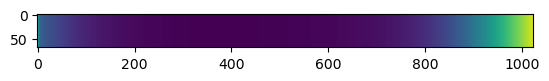

In [91]:
plt.imshow(spectrum0)

TypeError: Invalid shape (69631,) for image data

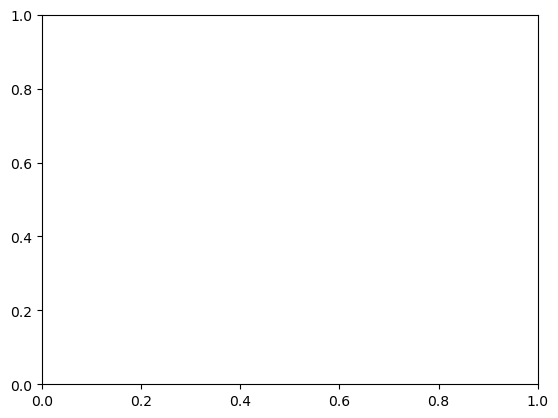

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# Load the spectrum data
spectrum = data['spectrum_1']

# Define the frequency range
freq_range = (19.2, 20000)
freqs = np.linspace(19, 20000, spectrum.shape[0])

# Find the indices of the frequency range
freq_index = np.where((freqs >= freq_range[0]) & (freqs <= freq_range[1]))[0]

# Select the frequency range from the spectrum data
spectrum_range = spectrum[freq_index]

# Create the plot
fig, ax = plt.subplots()
im = ax.imshow(spectrum_range.T, origin='lower', aspect='auto', cmap='jet')

# Add colorbar
cbar = fig.colorbar(im)

# Set the axis labels
ax.set_xlabel('Time')
ax.set_ylabel('Frequency (Hz)')

# Show the plot
plt.show()


TypeError: Invalid shape (69632,) for image data

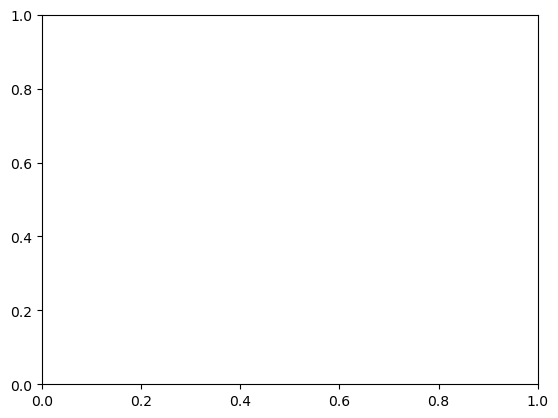

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# Load the spectrum data
spectrum = data['spectrum_1']

# Define the frequency range
freq_range = (19.2, 20000)
freqs = np.linspace(19.2, 20000, spectrum.shape[0])

# Find the indices of the frequency range
freq_index = np.where((freqs >= freq_range[0]) & (freqs <= freq_range[1]))[0]

# Select the frequency range from the spectrum data
spectrum_range = spectrum[freq_index]

# Create the plot
fig, ax = plt.subplots()
im = ax.imshow(spectrum_range.T, origin='lower', aspect='auto', cmap='jet')

# Add colorbar
cbar = fig.colorbar(im)

# Set the axis labels
ax.set_xlabel('Time')
ax.set_ylabel('Frequency (Hz)')

# Show the plot
plt.show()


In [92]:
spectrum_range

0       -11.236061
1       -11.552206
2       -11.761514
3       -11.867883
4       -11.927806
           ...    
69627   -11.325413
69628   -11.319762
69629   -11.314077
69630   -11.308358
69631   -11.302605
Name: spectrum_1, Length: 69632, dtype: float64

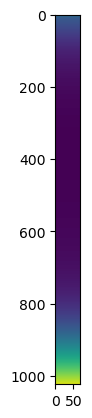

In [46]:
plt.imshow(spectrum0.T)

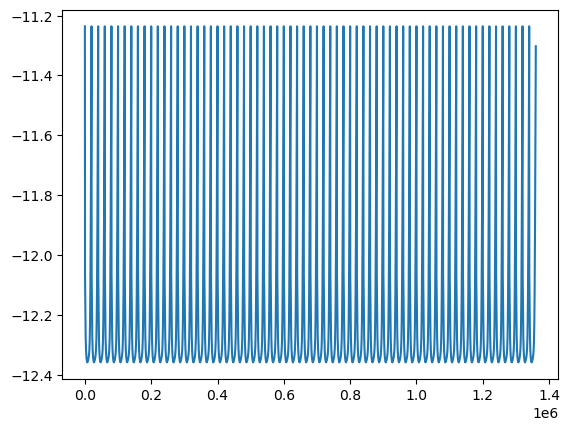

In [57]:
plt.plot(np.arange(69632)*19.53125, data.iloc[:69632].spectrum_0.values)

In [88]:
k=np.sqrt(data.iloc[:69632].spectrum_0)

c:\Users\HP\anaconda3\envs\DL\lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


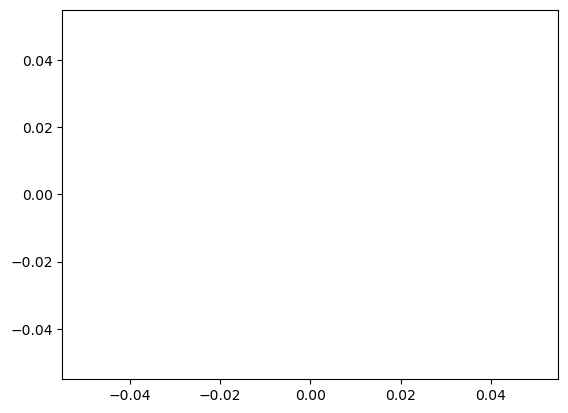

In [89]:
plt.plot(np.arange(69632)*19.53125, k)

In [30]:
data.iloc[1024:2048]

,Datetime,Geocentric_lat,Geocentric_long,Altitude,Local_time,spectrum_0,spectrum_1
1024,2004-07-05 08:00:37.830000,-0.5418,32.9799,708.455,10.2092,-11.236061,-11.236061
1025,2004-07-05 08:00:37.881200,-0.5418,32.9799,708.455,10.2092,-11.552206,-11.552206
1026,2004-07-05 08:00:37.932400,-0.5418,32.9799,708.455,10.2092,-11.761514,-11.761514
1027,2004-07-05 08:00:37.983600,-0.5418,32.9799,708.455,10.2092,-11.867883,-11.867883
1028,2004-07-05 08:00:38.034800,-0.5418,32.9799,708.455,10.2092,-11.927806,-11.927806
...,...,...,...,...,...,...,...
2043,2004-07-05 08:01:30.002800,-0.5418,32.9799,708.455,10.2092,-11.325413,-11.325413
2044,2004-07-05 08:01:30.054000,-0.5418,32.9799,708.455,10.2092,-11.319762,-11.319762
2045,2004-07-05 08:01:30.105200,-0.5418,32.9799,708.455,10.2092,-11.314077,-11.314077
2046,2004-07-05 08:01:30.156400,-0.5418,32.9799,708.455,10.2092,-11.308358,-11.308358


In [85]:
float(1024/2.048)


500.0

In [86]:
1/500.0

0.002